# Regression Using StatsModels
- Run a regression to find beta and alpha of FB to SPY
- FB<sub>t</sub> ~ $\beta$ * SPY<sub>t</sub> + $\alpha$ + e<sub>t</sub>

In [9]:
import statsmodels.api as sm
import pandas as pd
import numpy as np
import yfinance as yf 

# pip install yfinance
# https://pypi.org/project/yfinance/

In [10]:
# download price data
univ = ['SPY','META']
px = yf.download(univ, start="2016-01-01")['Close']

[*********************100%***********************]  2 of 2 completed


In [11]:
px

Ticker,META,SPY
Date,,
2016-01-04,101.510918,170.372192
2016-01-05,102.017387,170.660294
2016-01-06,102.255714,168.507584
2016-01-07,97.240746,164.464844
2016-01-08,96.654831,162.659576
...,...,...
2025-12-16,657.150024,676.869934
2025-12-17,649.500000,669.421936
2025-12-18,664.450012,674.476929


In [12]:
# get returns
ret = px / px.shift() - 1
ret

Ticker,META,SPY
Date,,
2016-01-04,NaN,NaN
2016-01-05,0.004989,0.001691
2016-01-06,0.002336,-0.012614
2016-01-07,-0.049043,-0.023991
2016-01-08,-0.006025,-0.010977
...,...,...
2025-12-16,0.014888,-0.002732
2025-12-17,-0.011641,-0.011004
2025-12-18,0.023018,0.007551


In [13]:
# set X and Y. Have to add constant
X = ret[['SPY']]
X = sm.add_constant(X)

Y = ret['META']

In [14]:
# observe x,y
print (X)
print (Y)

            const       SPY
Date                       
2016-01-04    1.0       NaN
2016-01-05    1.0  0.001691
2016-01-06    1.0 -0.012614
2016-01-07    1.0 -0.023991
2016-01-08    1.0 -0.010977
...           ...       ...
2025-12-16    1.0 -0.002732
2025-12-17    1.0 -0.011004
2025-12-18    1.0  0.007551
2025-12-19    1.0  0.009063
2025-12-22    1.0  0.004048

[2508 rows x 2 columns]
Date
2016-01-04         NaN
2016-01-05    0.004989
2016-01-06    0.002336
2016-01-07   -0.049043
2016-01-08   -0.006025
                ...   
2025-12-16    0.014888
2025-12-17   -0.011641
2025-12-18    0.023018
2025-12-19   -0.008548
2025-12-22    0.009366
Name: META, Length: 2508, dtype: float64


In [15]:
# can't do this - missing data
results = sm.OLS(Y, X).fit()

MissingDataError: exog contains inf or nans

In [16]:
# drop data
X = X.dropna()
Y = Y.dropna()
results = sm.OLS(Y, X).fit()

In [17]:
# check summary
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                   META   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     1517.
Date:                Mon, 22 Dec 2025   Prob (F-statistic):          8.06e-260
Time:                        15:19:30   Log-Likelihood:                 6356.9
No. Observations:                2507   AIC:                        -1.271e+04
Df Residuals:                    2505   BIC:                        -1.270e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      0.613      0.540      -0.001       0.001
SPY            1.3136      0.034     38.944      0.000       1.248       1.380
==============================================================================
Omnibus:                      851.612   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):           135534.120
Skew:                          -0.447   Prob(JB):                         0.00
Kurtosis:                      39.010   Cond. No.                         88.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [18]:
# get params
results.params

const    0.000235
SPY      1.313646
dtype: float64

In [19]:
# get tvalues
results.tvalues

const     0.612560
SPY      38.944005
dtype: float64

Reconstruct FB
- FB<sub>t</sub> ~ $\beta$ * SPY<sub>t</sub> + $\alpha$ + e<sub>t</sub>

In [21]:
FB = results.params['SPY']*X['SPY'] + results.params['const'] + results.resid

In [22]:
# basically identical
(FB-Y).abs().sum()

np.float64(1.3839840731777464e-16)

In [31]:
beta_contr = results.params['SPY']*X['SPY']
prediction = results.params['SPY']*X['SPY'] + results.params['const']
alpha_contr = results.params['const'] + results.resid

In [30]:
beta_contr

Date
2016-01-05    0.002221
2016-01-06   -0.016570
2016-01-07   -0.031516
2016-01-08   -0.014419
2016-01-11    0.001301
                ...   
2025-12-16   -0.003589
2025-12-17   -0.014455
2025-12-18    0.009920
2025-12-19    0.011906
2025-12-22    0.005317
Name: SPY, Length: 2507, dtype: float64

In [24]:
alpha_contr

Date
2016-01-05    0.002768
2016-01-06    0.018906
2016-01-07   -0.017527
2016-01-08    0.008394
2016-01-11    0.000549
                ...   
2025-12-16    0.018477
2025-12-17    0.002814
2025-12-18    0.013098
2025-12-19   -0.020455
2025-12-22    0.004048
Length: 2507, dtype: float64

<Axes: xlabel='Date'>

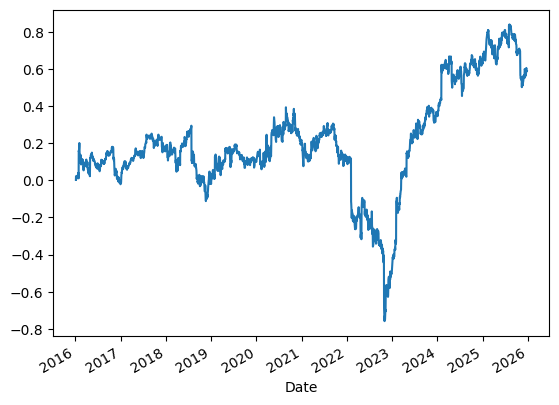

In [25]:
alpha_contr.cumsum().plot()

In [26]:
# correl is zero to spy
alpha_contr.corr(X['SPY'])

np.float64(6.576196958289119e-16)

In [27]:
# "alpha"
alpha_contr.mean()

np.float64(0.00023492244257918767)

In [28]:
# information ratio
alpha_contr.mean()/alpha_contr.std()*np.sqrt(252)

np.float64(0.194537367328453)

In [29]:
# alpha t-stat
results.tvalues['const']

np.float64(0.6125604917143826)